# Datasaurus Dozen Why Visualization Matters

## Load the dataset

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

#---------------------------------------------------------
# 1. READING A FILE FROM A PUBLIC REPOSITORY IN GITHUB
#---------------------------------------------------------
#  To read a file from GitHub: First, define the GitHub URL for the file
# You must replace 'github.com' with 'raw.githubusercontent.com' and
# remove the 'tree' part from the path


raw_url = "https://raw.githubusercontent.com/jsancheg/DemoClass/main/data/raw/datasaurus_dozen.csv"

# 2. Use pandas.read_csv() to load the file directory

try:
    df = pd.read_csv(raw_url)

    # 3. Display the first few rows to confirm it loaded correctly
    print("Dataset loaded successfully!")
    print(df.head())

    # 4. Display information about the Dataframe
    print("\nDataFrame Information.")

    df.info()

except Exception as e:
    print("An error ocurred while loading the dataset: {e}")


    

Dataset loaded successfully!
  dataset        x        y
0    dino  55.3846  97.1795
1    dino  51.5385  96.0256
2    dino  46.1538  94.4872
3    dino  42.8205  91.4103
4    dino  40.7692  88.3333

DataFrame Information.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1846 entries, 0 to 1845
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   dataset  1846 non-null   object 
 1   x        1846 non-null   float64
 2   y        1846 non-null   float64
dtypes: float64(2), object(1)
memory usage: 43.4+ KB


## Plot the datasets

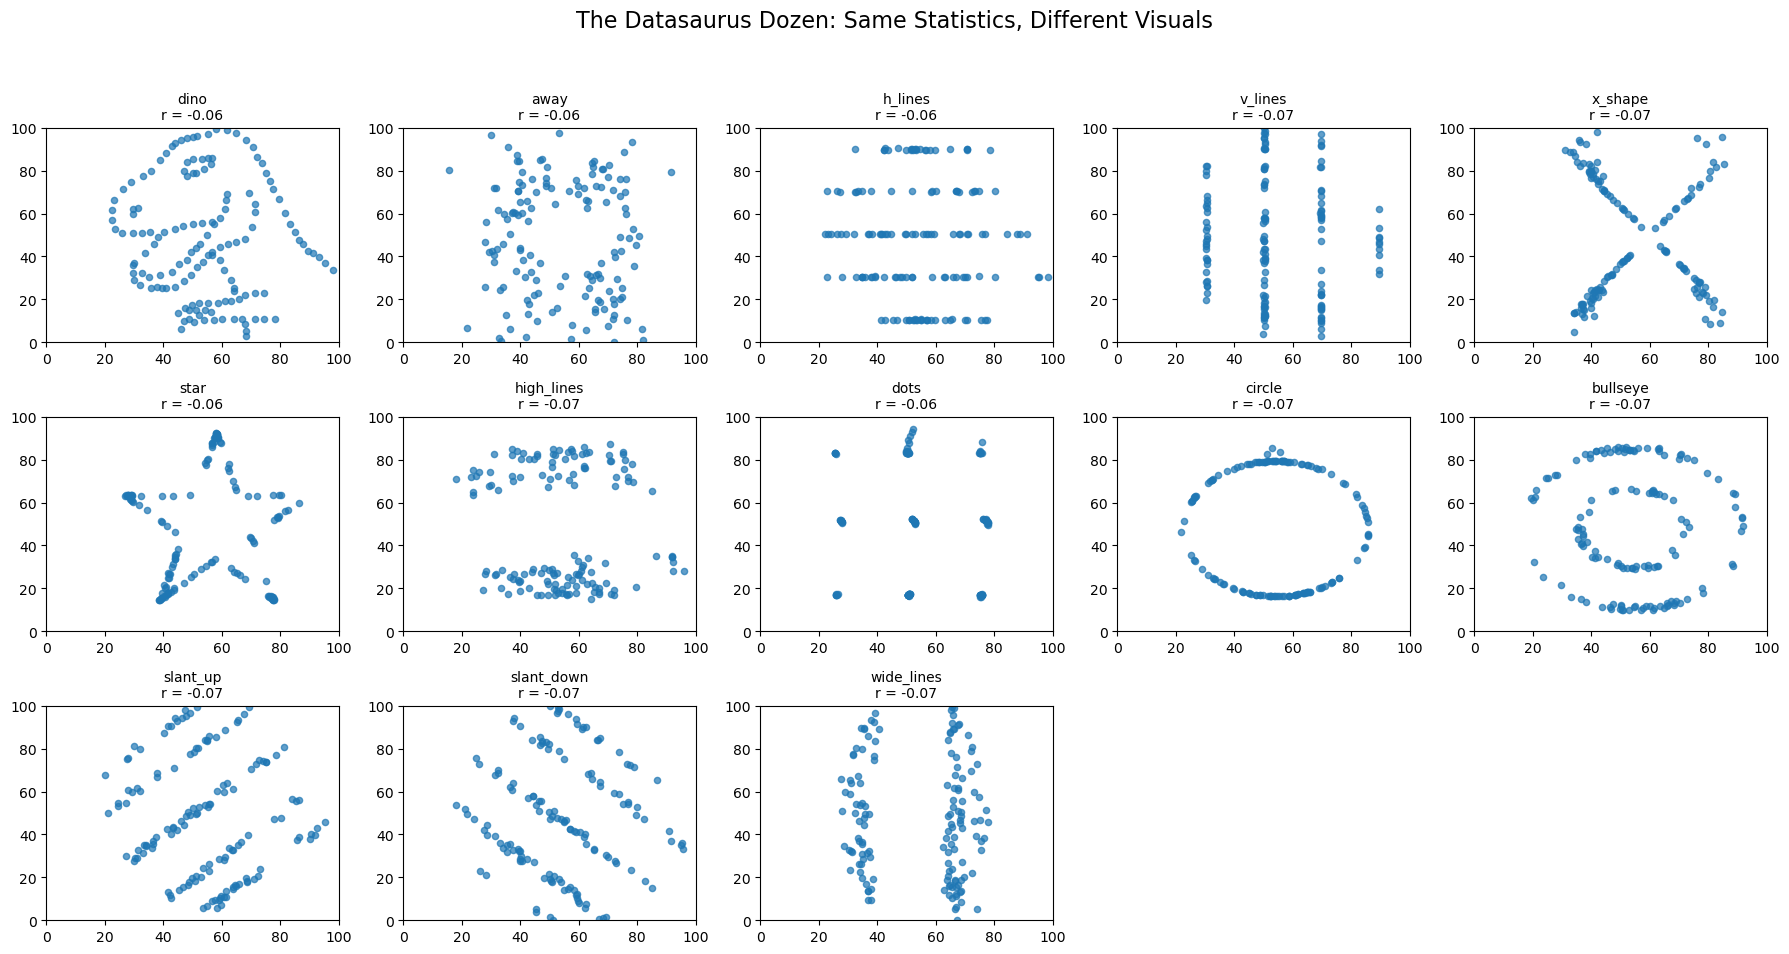

In [8]:

datasets = df['dataset'].unique()
fig, axes = plt.subplots(3, 5, figsize=(18, 10)) # Increased figsize for better resolution
fig.suptitle('The Datasaurus Dozen: Same Statistics, Different Visuals', fontsize=16)

# Flatten the axes array to easily iterate through each subplot
axes = axes.flatten()

# --- 3. Iterate and Plot Each Dataset ---
for i, dataset_name in enumerate(datasets):
    # Filter the DataFrame for the current dataset
    subset = df[df['dataset'] == dataset_name]
    
    # Calculate the correlation for the title
    # Note: .corr() requires a DataFrame; .iloc[0, 1] extracts r_xy
    r_value = subset[['x', 'y']].corr().iloc[0, 1]

    # Create the scatter plot on the current axis (axes[i])
    axes[i].scatter(subset['x'], subset['y'], alpha=0.7, s=20) # s=20 sets the marker size
    
    # Set the title, including the correlation value (r)
    axes[i].set_title(f'{dataset_name}\nr = {r_value:.2f}', fontsize=10)
    
    # Ensure consistent axis limits for comparison
    axes[i].set_xlim(0, 100)
    axes[i].set_ylim(0, 100)
    
# --- 4. Clean up unused subplots ---
# Since we have 13 datasets in a 15-plot grid, hide the remaining two empty axes.
for j in range(len(datasets), len(axes)):
    fig.delaxes(axes[j])

# --- 5. Display the plot ---
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
plt.show()

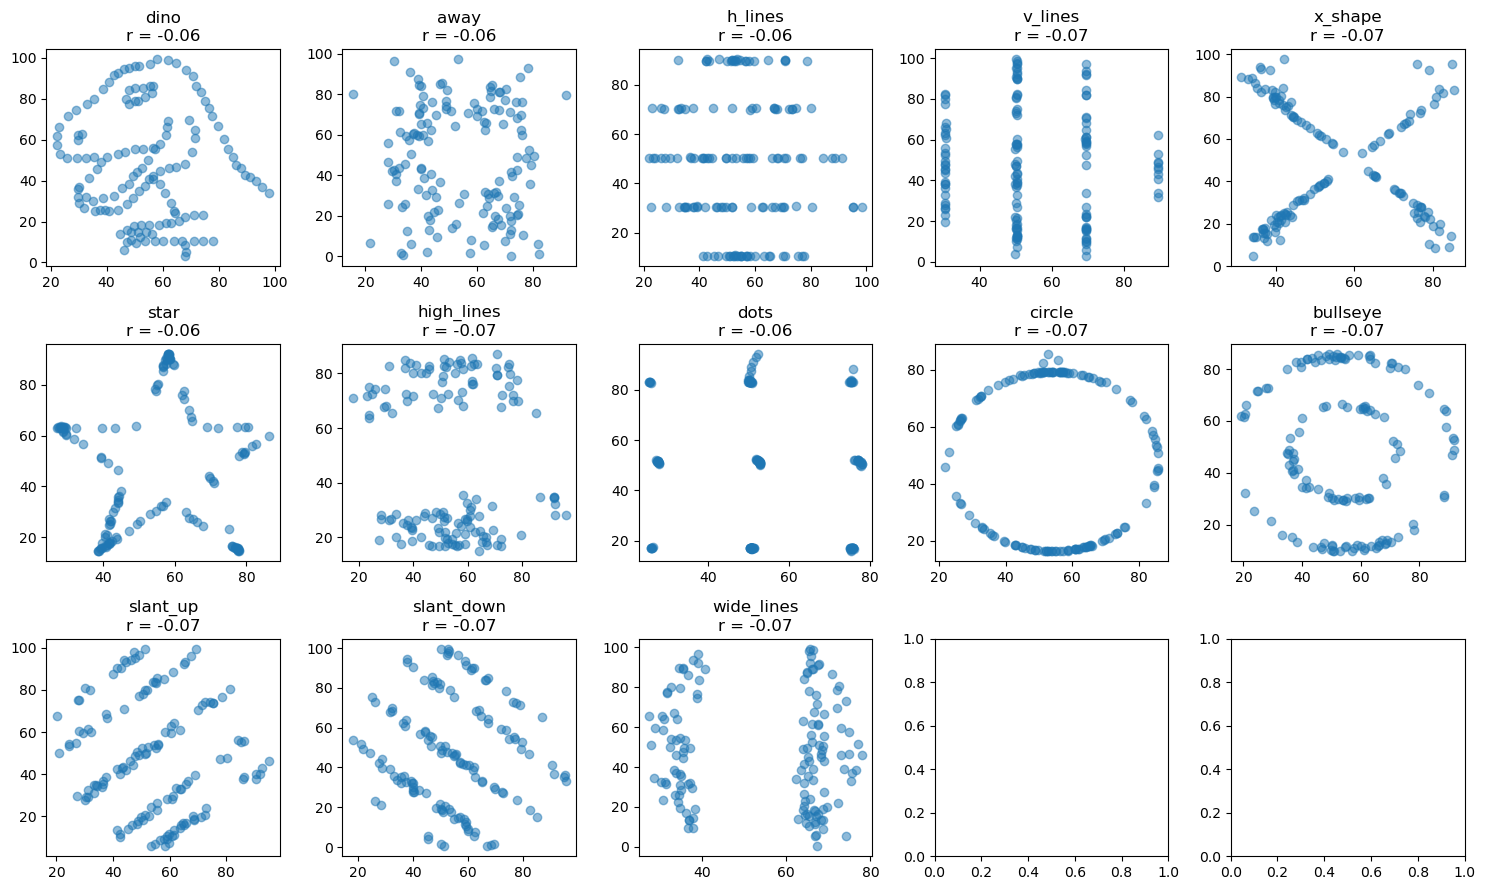

In [12]:

# Load datasaurus
raw_url = "https://raw.githubusercontent.com/jsancheg/DemoClass/main/data/raw/datasaurus_dozen.csv"
data = pd.read_csv(raw_url)
# Plot all 13 datasets
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
datasets = df['dataset'].unique()

for ax, dataset in zip(axes.flatten(), datasets):
    subset = data[data['dataset'] == dataset]
    ax.scatter(subset['x'], subset['y'], alpha=0.5)
    correlation_value = subset[['x', 'y']].corr().iloc[0,1]
    
    ax.set_title(f'{dataset}\nr = {correlation_value:.2f}')

plt.tight_layout()
plt.show()

## Calculate the statistics

In [2]:
# Calculating the statistics
# mean calculation
x_mean = df['x'].mean()
y_mean = df['y'].mean()

# Standard deviation calculation
x_std = df['x'].std()
y_std = df['y'].std()

# Correlation calculation
correlation_r = df[['x', 'y']].corr().iloc[0,1]
# --- Display Results ---

print("--- Calculated Summary Statistics ---")
print(f"Mean of x (x̄): {x_mean:.4f}")
print(f"Mean of y (ȳ): {y_mean:.4f}")
print(f"Standard Deviation of x (σₓ): {x_std:.4f}")
print(f"Standard Deviation of y (σᵧ): {y_std:.4f}")
print(f"Correlation (r): {correlation_r:.4f}")




--- Calculated Summary Statistics ---
Mean of x (x̄): 54.2657
Mean of y (ȳ): 47.8351
Standard Deviation of x (σₓ): 16.7130
Standard Deviation of y (σᵧ): 26.8478
Correlation (r): -0.0660
